____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, compute_mean_square, compute_mean_square_groupby, plot_error

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter', '0.5cpd', '1.5cpd', '2.5cpd', '3cpd']),
 dict_keys(['swot250naive', 'swot250gauss1e3', 'swot250gauss2e3', 'swot250gauss3e3', 'swot250gauss4e3', 'swot250gauss5e3', 'swot2kmnaive', 'swot2kmgauss1e3', 'swot2kmgauss2e3', 'swot2kmgauss3e3', 'swot2kmgauss4e3', 'swot2kmgauss5e3', 'swot2kmgauss1e4']),
 dict_keys(['era5']))

_______
# Compute and project (x = cross, y = alg)

In [3]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etac', wd_depth='0', wd_model='rio'), 
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etac', wd_depth='15', wd_model='rio')]

DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<12).dropna('row_number')

DSS = DS.where(DS.depth==0, drop=True).isel(id_comb=[0])
DSD = DS.where(DS.depth==15, drop=True).isel(id_comb=[1])

nofilter__swot2kmnaive_etac__rio_0era5
nofilter__swot2kmnaive_etac__rio_15era5
Identified SWOT and drifter outliers have been removed


In [4]:
DS

<xarray.Dataset> Size: 188MB
Dimensions:        (id_comb: 2, row_number: 289455)
Coordinates:
    datetime       (id_comb, row_number) datetime64[ns] 5MB 2023-04-01T11:50:...
    longitude      (id_comb, row_number) float64 5MB 4.812 4.812 ... 2.415 2.414
    latitude       (id_comb, row_number) float64 5MB 42.22 42.22 ... 39.79 39.79
    pass_number    (id_comb, row_number) int64 5MB 3 3 3 3 3 ... 16 16 16 16 16
    time_to_swot   (id_comb, row_number) timedelta64[ns] 5MB 11:52:32.696536 ...
    cycle_number   (id_comb, row_number) int64 5MB 478 478 478 ... 577 577 577
    drifter_id     (id_comb, row_number) object 5MB '300534060315840' ... '30...
    drifter_type   (id_comb, row_number) object 5MB 'SVP' 'SVP' ... 'SVP' 'SVP'
    depth          (id_comb, row_number) int64 5MB 15 15 15 15 ... 15 15 15 15
    phi            (id_comb, row_number) float64 5MB 0.2389 0.2389 ... 2.917
  * row_number     (row_number) int64 2MB 0 1 2 3 ... 404302 404303 404304
  * id_comb        (id_comb) <U39 312B 'nofilter__swot2kmnaive_etac__rio_0era...
Data variables: (12/30)
    sume           (id_comb, row_number) float64 5MB 4.183e-05 ... 1.669e-05
    acce           (id_comb, row_number) float64 5MB 6.386e-06 ... -1.995e-06
    exce_acc       (id_comb, row_number) float64 5MB 3.544e-05 ... 1.868e-05
    core           (id_comb, row_number) float64 5MB -1.001e-05 ... -1.024e-05
    exce_cor       (id_comb, row_number) float64 5MB 5.184e-05 ... 2.693e-05
    ggde           (id_comb, row_number) float64 5MB 1.977e-05 ... 3.007e-05
    ...             ...
    prodn_acc_cor  (id_comb, row_number) float64 5MB -7.476e-11 ... -1.039e-10
    prodn_acc_ggd  (id_comb, row_number) float64 5MB -3.151e-10 ... -1.523e-10
    prodn_acc_wd   (id_comb, row_number) float64 5MB -9.676e-11 ... -1.205e-11
    prodn_cor_ggd  (id_comb, row_number) float64 5MB 1.607e-10 ... 2.394e-10
    prodn_cor_wd   (id_comb, row_number) float64 5MB 4.934e-11 ... 1.894e-11
    prodn_ggd_wd   (id_comb, row_number) float64 5MB 2.079e-10 ... 2.778e-11

In [5]:
# rotate
def rotate(e, n, phi):
    return np.cos(phi)*e - np.sin(phi)*n, np.sin(phi)*e + np.cos(phi)*n

def crossalg_proj(dsen):
    ds = dsen.copy()
    ds['sumx'] , ds['sumy'] = rotate(dsen.sume, dsen.sumn, dsen.phi)
    dsxy = ds[['sumx','sumy']]
    var = ['acc', 'cor', 'ggd', 'wd', 'sum']
    prod  = [l for l in ds.keys() if 'prodn' in l]
    exc  = [l for l in ds.keys() if 'excn' in l]
    for v in var :
        dsxy[v +'x'] , dsxy[v +'y'] = rotate(dsen[v+'e'], dsen[v+'n'], dsen.phi)

    for direction in ['x', 'y'] : 
            if direction == 'x' : l = {'acc':'accx', 'cor':'corx', 'ggd':'ggdx', 'wd':'wdx'}
            if direction == 'y' : l = {'acc':'accy', 'cor':'cory', 'ggd':'ggdy', 'wd':'wdy'}
                
            # sum 
            dsxy['sum'+direction] = sum([dsxy[l[v]] for v in l])
            
            # simple var + sum- one term
            for v in l :
                dsxy[l[v]] = dsxy[l[v]]
                dsxy['exc'+direction+'_'+v] = dsxy['sum'+direction]-dsxy[l[v]]
                
            #2 by 2 product    
            import itertools  
            couple = list(itertools.combinations(list(l.keys()),2))
            for c in couple : 
                dsxy['prod'+direction+'_'+'_'.join(c)] = dsxy[c[0]+direction] * dsxy[c[1]+direction]
    return dsxy
    
DSr =  crossalg_proj(DS)  

DSSr = DSr.where(DSr.depth==0, drop=True).isel(id_comb=[0])
DSDr = DSr.where(DSr.depth==15, drop=True).isel(id_comb=[1])


__________________
## Surface

152325
10.110166786192291
12.225425535350407
9.478894650129835
10.138384263326678


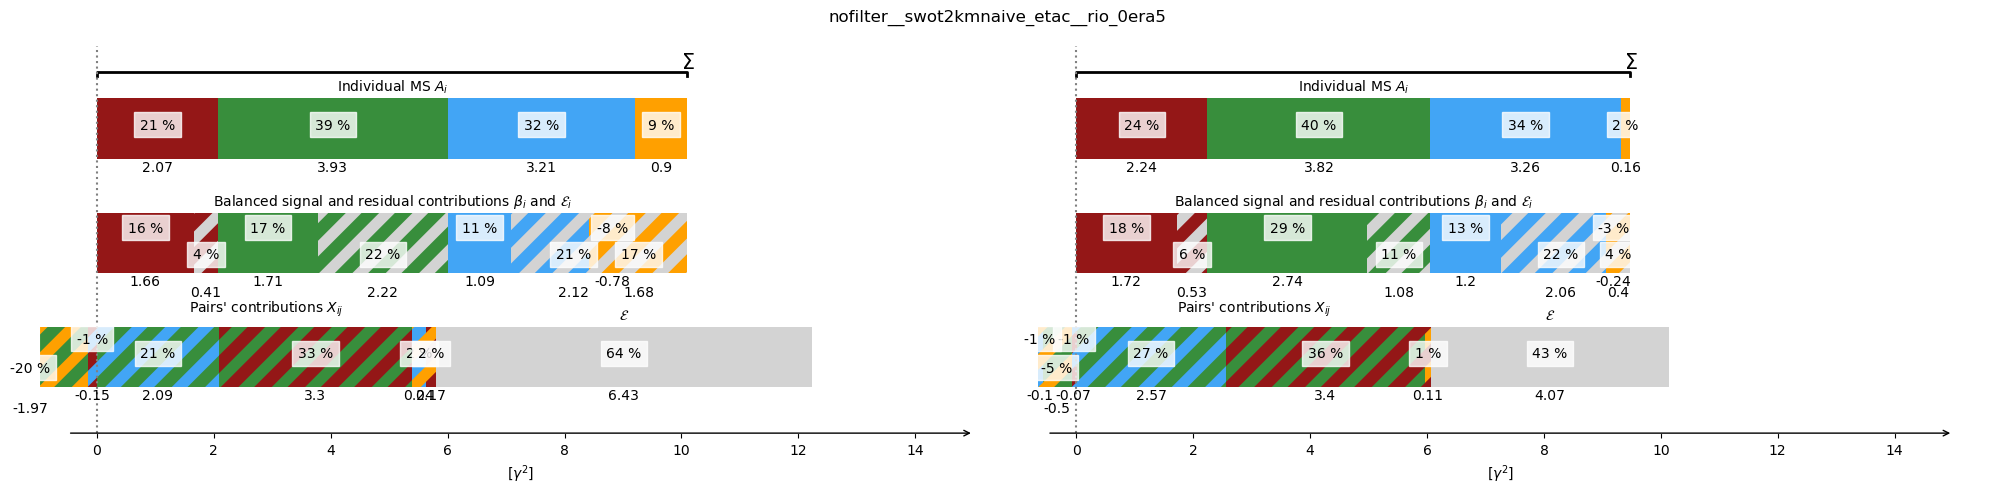

In [8]:
ds = compute_mean_square(DSS, dirname=('e', 'n'))/U2
df = ds.to_dataframe()
print(DSS.sizes['row_number'])
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 15])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 15])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', c + '_Xy.png'))

152325
9.821616531726617
11.92245760827377
9.767444904595509
10.418637784735974


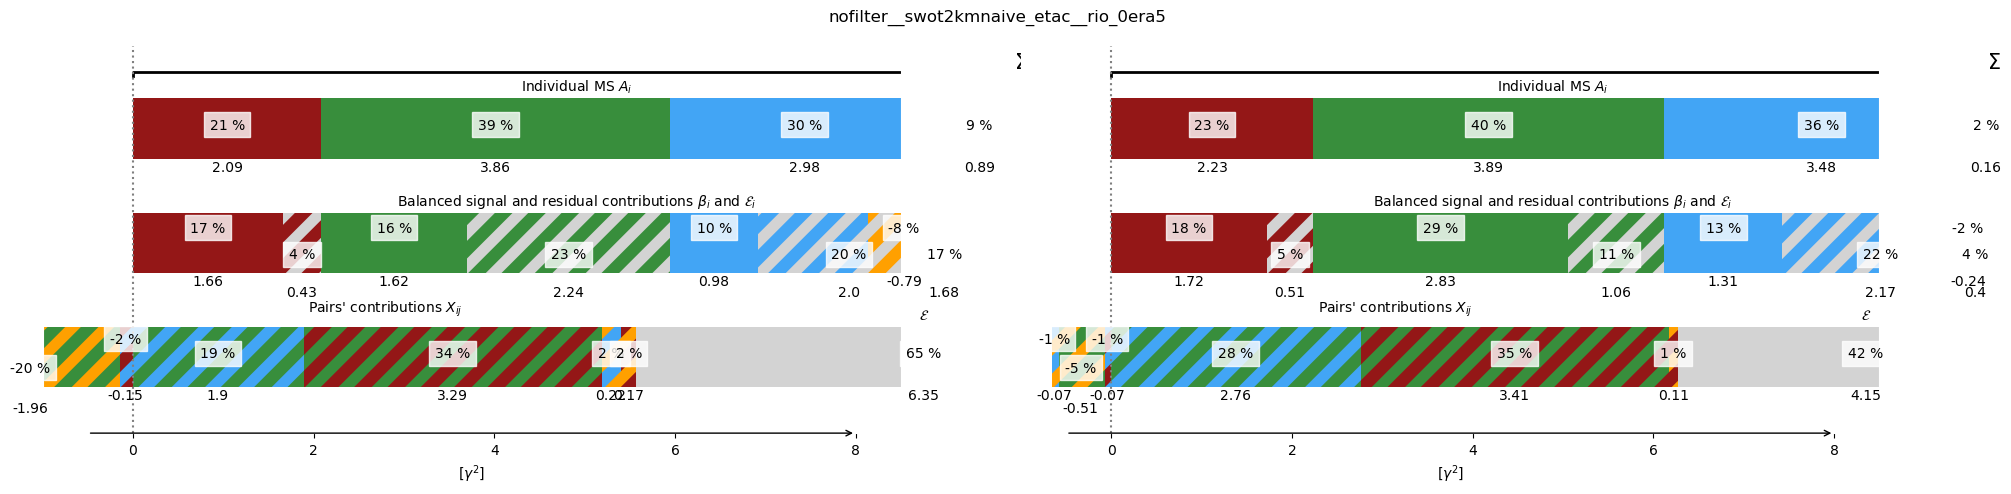

In [9]:
dsr = compute_mean_square(DSSr, dirname=('x', 'y'))/U2
df = dsr.to_dataframe()
print(DSSr.sizes['row_number'])
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='x', xlim=[-1, 8])
    synthetic_figure(df.loc[c], axs[1], dir='y', xlim=[-1, 8])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', c + '_XY.png'))

_____
# Join pdf Sea-state/cross-track distance

In [10]:
def plot_join_pdfs(ds, x, y, binx=100, biny=100):
    nsamples, yy, xx = np.histogram2d(ds[y], ds[x], bins=(biny, binx))
    da = xr.DataArray(data=nsamples, dims=[y, x],coords={x:([x], (xx[:-1] + xx[1:])/2), y:([y], (yy[:-1] + yy[1:])/2)})
    
    fig = plt.figure(figsize=(9, 4))
    
    # Add a gridspec with two rows and two columns and a ratio of 2 to 7 between
    # the size of the marginal axes and the main axes in both directions.
    # Also adjust the subplot parameters for a square plot.
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=(7, 2),
        height_ratios=(2, 7),
        left=0.1,
        right=0.9,
        bottom=0.1,
        top=0.9,
        wspace=0.05,
        hspace=0.05,
    )
    
    ax = fig.add_subplot(gs[1, 0])
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
    

    
    da.plot(ax=ax, add_colorbar=False)
    #da.plot.contour(ax=ax, add_colorbar=False, colors='orange')
    #ax.plot(xx, -xx, color='r')
    ds[x].plot.hist(bins=binx, density=True, ax=ax_histx, zorder=1)
    ds[y].plot.hist(
        bins=biny,
        density=True,
        ax=ax_histy,
        orientation="horizontal",
        zorder=1,
    )


    # no labels
    ax.grid(zorder=0)
    ax_histx.grid()
    ax_histy.grid()
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histy.set_title('')
    ax_histx.set_title('')
    ax_histy.set_xlabel('')
    ax_histx.set_xlabel('')
    fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_66604/2910541907.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)


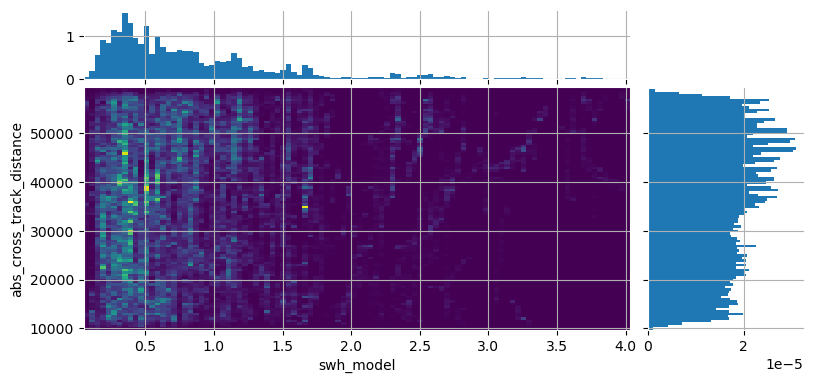

In [11]:
dfr = DSSr.to_dataframe().reset_index().set_index('row_number')
dfs = pd.read_csv(ALTI['swot2kmnaive']).set_index('row_number')
dfs['abs_cross_track_distance'] = abs(dfs['cross_track_distance'])

dfrr = pd.concat([dfs[['swh_model', 'abs_cross_track_distance']], dfr], axis=1).dropna()

dss = dfrr.to_xarray()
plot_join_pdfs(dss, 'swh_model', 'abs_cross_track_distance', binx=100, biny=100)

In [12]:
def plot_error(df, x, v, ax):
    ax.fill_between(
        df[x], df[v] - df["ber__" + v], df[v] + df["ber__" + v], color="silver"
    )

_________
# Dependency on the cross_track distance

In [16]:
bootstrap =False
dfct = dfrr[dfrr.swh_model<1]
ct_dist_bins = np.arange(0, 70000, 1000)
dfct['abs_cross_track_distance_cut'] = pd.cut(dfct['abs_cross_track_distance'], ct_dist_bins, labels=(ct_dist_bins[1:] + ct_dist_bins[:-1])/2)
dsc = compute_mean_square_groupby(dfct, groupby = 'abs_cross_track_distance_cut', dirname = ('x', 'y'), bootstrap=bootstrap, vars_errors = ['Ex_ggd', 'Ey_ggd']  )
dsc['meanbin_swh_model'] = dfct.groupby('abs_cross_track_distance_cut', observed=bootstrap).swh_model.mean().dropna().to_xarray()
dsc = dsc.where(dsc.nb_coloc>100)
dsc['abs_cross_track_distance_cut'] = dsc['abs_cross_track_distance_cut']/1000

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_66604/497731885.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfct['abs_cross_track_distance_cut'] = pd.cut(dfct['abs_cross_track_distance'], ct_dist_bins, labels=(ct_dist_bins[1:] + ct_dist_bins[:-1])/2)


In [20]:
dfs.columns

Index(['longitude', 'latitude', 'ancillary_surface_classification_flag',
       'cross_track_distance', 'duacs_editing_flag', 'duacs_phase_screen',
       'duacs_phase_screen_orbit', 'duacs_phase_screen_static',
       'duacs_relative_vorticity', 'duacs_speed_meridional',
       'duacs_speed_meridional_abs', 'duacs_speed_zonal',
       'duacs_speed_zonal_abs', 'duacs_strain', 'duacs_xcal', 'sig0_karin_2',
       'phi', 'swh_model', 'ssh_karin_uncert',
       'ggdx_cvl_mean_dynamic_topography_cnes_cls_22',
       'ggdx_distance_to_coast', 'ggdx_cvl_mean_sea_surface_cnes_22_hybrid',
       'ggdx_cvl_ocean_tide_fes_2022', 'ggdx_cvl_ssha_reference',
       'ggdx_duacs_ssha_karin_2_calibrated',
       'ggdx_duacs_ssha_karin_2_filtered', 'ggdx_duacs_ssha_karin_2_oi',
       'ggdx_internal_tide_hret', 'ggdx_mean_sea_surface_cnescls',
       'ggdx_ocean_tide_fes', 'ggdx_ssh_karin_uncert',
       'ggdy_cvl_mean_dynamic_topography_cnes_cls_22',
       'ggdy_distance_to_coast', 'ggdy_cvl_mean_sea

In [134]:
dsc.meanbin_swh_model.min()

<xarray.DataArray 'meanbin_swh_model' ()> Size: 8B
array(0.28436847)

KeyError: "No variable named 'ber__E_ggd'. Variables on the dataset include ['ACCx', 'CORx', 'GGDx', 'WDx', 'Sx', ..., 'Xy_ggd_wd', 'nb_coloc', 'meanbin_swh_model', 'abs_cross_track_distance_cut', 'E_ggd']"

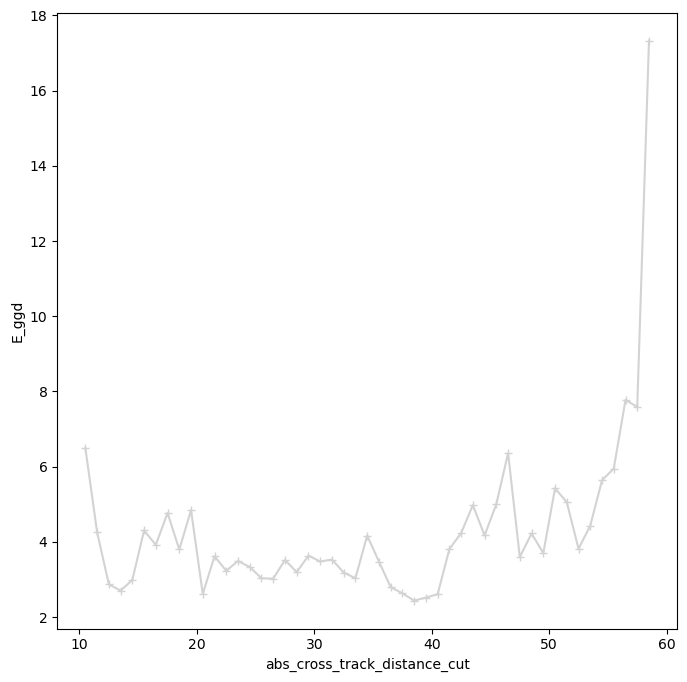

In [18]:
dsc = dsc.dropna('abs_cross_track_distance_cut')

plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dsc['E_ggd'] = dsc.Ex_ggd + dsc.Ey_ggd
#dsc['ber__E_ggd'] = dsc.ber__Ex_ggd + dsc.ber__Ey_ggd
#dsc.Ex_ggd.plot(ax=ax, marker='+')
#dsc.Ey_ggd.plot(ax=ax, marker='+')
dsc.E_ggd.plot(ax=ax, marker='+', c='lightgrey')
plot_error(dsc, 'abs_cross_track_distance_cut', 'E_ggd', ax=ax)
sc = dsc.plot.scatter(x = 'abs_cross_track_distance_cut', y='E_ggd', c=dsc.meanbin_swh_model,zorder=10)
plt.colorbar(sc, label ='Mean swh on the bin [m]')
ax.grid()
ax.set_ylabel(r'Pressure gradient residual contribution [$\gamma^2$]')
ax.set_xlabel(r'Cross - track distance [km]')

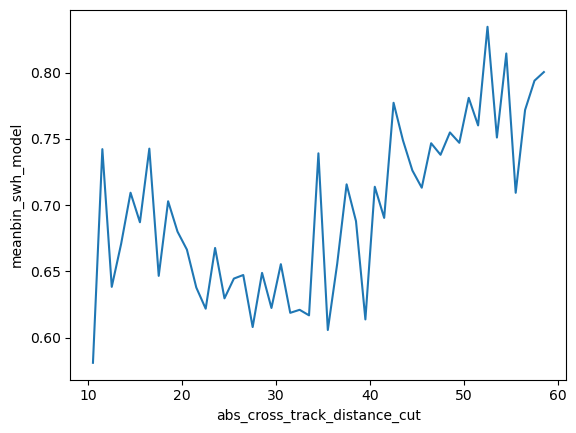

In [167]:
dsc.meanbin_swh_model.plot()

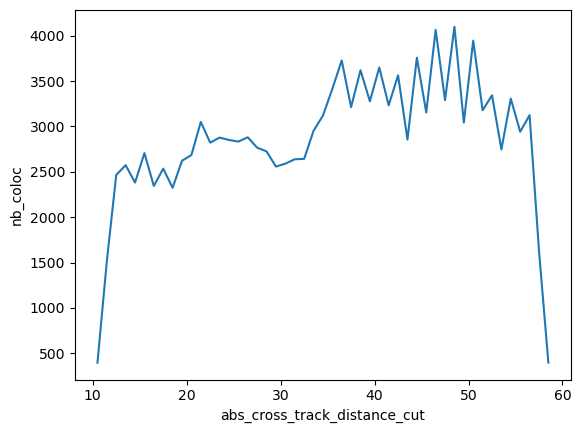

In [168]:
dsc.nb_coloc.plot()

Text(0.5, 0, 'Cross - track distance [km]')

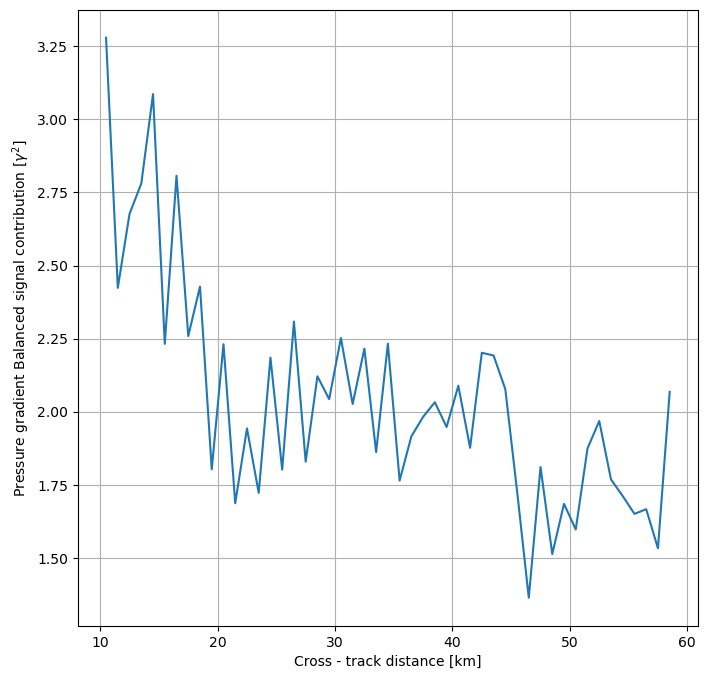

In [169]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
(dsc.Bx_ggd + dsc.By_ggd).plot(ax=ax)
ax.grid()
ax.set_ylabel(r'Pressure gradient Balanced signal contribution [$\gamma^2$]')
ax.set_xlabel(r'Cross - track distance [km]')

_________
# Dependency on the seastate

In [ ]:
bootstrap = True

dfswh = dfrr[(dfrr.abs_cross_track_distance>20e3) & (dfrr.abs_cross_track_distance<50e3)]
swh_dist_bins = np.linspace(0, 4.4, 100)
dfswh['swh_model_cut'] = pd.cut(dfswh['swh_model'], swh_dist_bins, labels=(swh_dist_bins[1:] + swh_dist_bins[:-1])/2)
dsswh = compute_mean_square_groupby(dfswh, groupby = 'swh_model_cut', dirname = ('x', 'y'), bootstrap=bootstrap, vars_errors = ['Ex_ggd', 'Ey_ggd'] )
dsswh['meanbin_abs_cross_track_distance'] = dfswh.groupby('swh_model_cut', observed=False).abs_cross_track_distance.mean().dropna().to_xarray()
dsswh = dsswh.where(dsswh.nb_coloc>0).dropna()

In [22]:
dsswh = dsswh.where(dsswh.nb_coloc>0).dropna('swh_model_cut')

Text(0.5, 0, 'Sea wave height from model [m]')

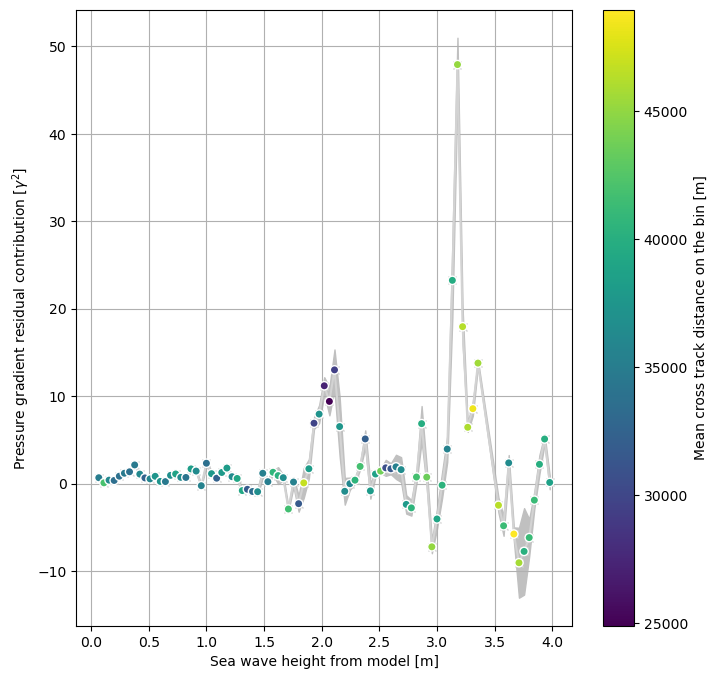

In [28]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dsswh['E_ggd'] = dsswh.Ex_ggd + dsswh.Ey_ggd
dsswh['ber__E_ggd'] = dsswh.ber__Ex_ggd + dsswh.ber__Ey_ggd
dsswh.E_ggd.plot(ax=ax, marker = 'x', c='lightgrey')
plot_error(dsswh, 'swh_model_cut', 'E_ggd', ax=ax)
sc = dsswh.plot.scatter(x = 'swh_model_cut', y='E_ggd', c=dsswh.meanbin_abs_cross_track_distance,zorder=10)
plt.colorbar(sc, label ='Mean cross track distance on the bin [m]')
ax.grid()
ax.set_ylabel(r'Pressure gradient residual contribution [$\gamma^2$]')
ax.set_xlabel(r'Sea wave height from model [m]')

Text(0.5, 0, 'Sea wave height from model [m]')

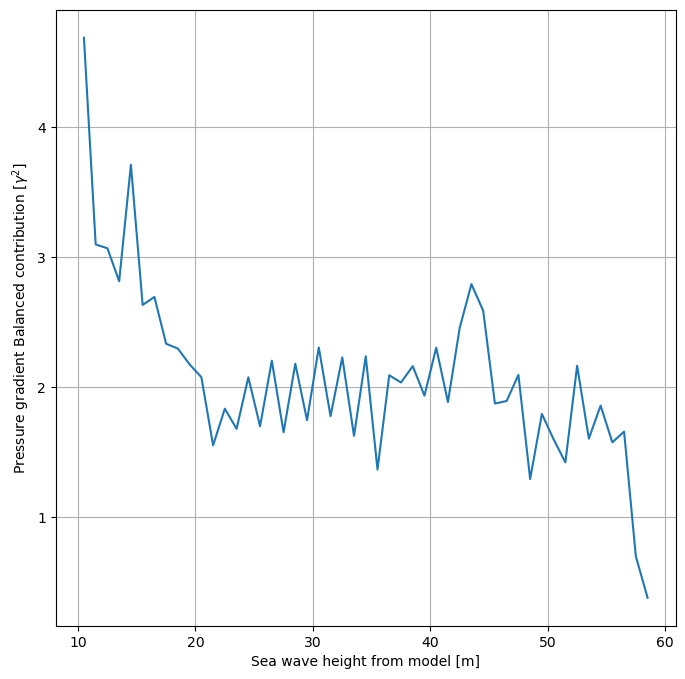

In [103]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
(dsc.Bx_ggd + dsc.By_ggd).plot(ax=ax)
ax.grid()
ax.set_ylabel(r'Pressure gradient Balanced contribution [$\gamma^2$]')
ax.set_xlabel(r'Sea wave height from model [m]')

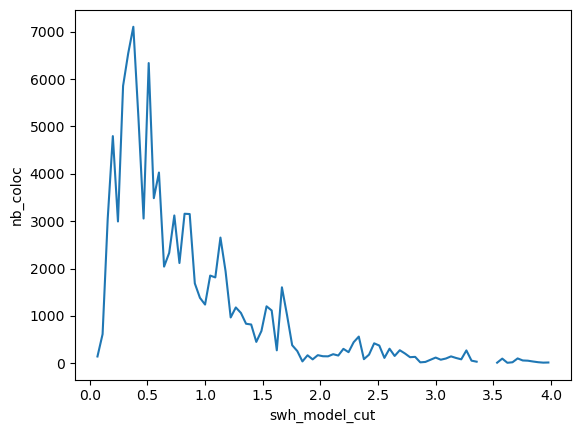

In [104]:
dsswh.nb_coloc.plot()